# EDA Visualizations

This notebook follows a step-by-step EDA flow, where each markdown section is placed directly above its corresponding code cell and output.

## Step 1: Load and clean the dataset
Load the CSV, standardize column names, coerce key numeric columns, and run basic data quality checks (shape, dtypes, missingness, duplicates).

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Load data
csv_path = "../data/llm_price_performance_tracker_2026-03-31.csv"
df = pd.read_csv(csv_path)

# Standardize column names
rename_map = {
    c: c.strip().lower().replace("\n", "_").replace(" ", "_").replace("-", "_")
    for c in df.columns
}
df = df.rename(columns=rename_map)

# Core numeric columns needed for current and upcoming tasks
numeric_cols = [
    "aa_intelligence_index",
    "input_cost_usd_per_1m",
    "output_cost_usd_per_1m",
    "blended_cost_usd_per_1m",
    "output_tokens_per_second",
    "time_to_first_token_s",
    "chatbot_arena_elo",
    "gpqa_diamond",
    "humanitys_last_exam",
    "livecodebench",
    "scicode",
    "math_500",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Cleaned working copy for EDA
df_clean = df.copy()

print(f"Shape: {df_clean.shape}")
print("\nDtypes (selected):")
print(df_clean[[c for c in ["model_name", "provider", "pricing_tier", "aa_intelligence_index"] if c in df_clean.columns]].dtypes)

print("\nMissingness (%), top 12 columns:")
print((df_clean.isna().mean() * 100).sort_values(ascending=False).head(12).round(2))

if "model_slug" in df_clean.columns:
    print(f"\nDuplicate model_slug rows: {df_clean.duplicated(subset=['model_slug']).sum()}")
if "aa_id" in df_clean.columns:
    print(f"Duplicate aa_id rows: {df_clean.duplicated(subset=['aa_id']).sum()}")

Shape: (453, 34)

Dtypes (selected):
model_name                object
provider                  object
pricing_tier              object
aa_intelligence_index    float64
dtype: object

Missingness (%), top 12 columns:
chatbot_arena_elo           89.85
elo_benchmark_blend         89.85
arena_votes                 89.85
arena_elo_ci95              89.85
aime_2025                   57.17
math_500                    55.63
speed_per_dollar            41.94
aa_math_index               40.84
time_to_first_token_s       38.41
output_tokens_per_second    38.41
time_to_first_answer_s      38.41
parameter_count             36.87
dtype: float64

Duplicate model_slug rows: 0
Duplicate aa_id rows: 0


## Step 2: Top-10 providers by model count
Group by `provider`, compute counts, and visualize the top 10 providers using a labeled horizontal bar chart.

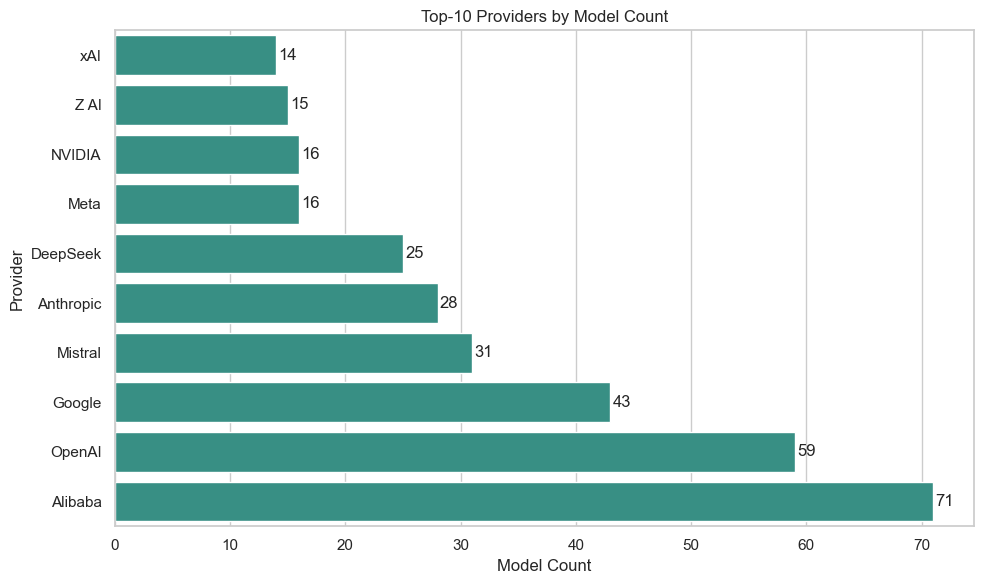

provider
xAI          14
Z AI         15
NVIDIA       16
Meta         16
DeepSeek     25
Anthropic    28
Mistral      31
Google       43
OpenAI       59
Alibaba      71
Name: count, dtype: int64

In [2]:
# Top-10 providers by model count
provider_counts = (
    df_clean["provider"]
    .dropna()
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=provider_counts.values, y=provider_counts.index, color="#2a9d8f")
ax.set_title("Top-10 Providers by Model Count")
ax.set_xlabel("Model Count")
ax.set_ylabel("Provider")

for i, v in enumerate(provider_counts.values):
    ax.text(v + 0.2, i, str(v), va="center")

plt.tight_layout()
plt.show()

provider_counts

## Step 3: Box plot of intelligence by pricing tier
Compare `aa_intelligence_index` distributions across `pricing_tier` categories with a box plot and overlaid points.

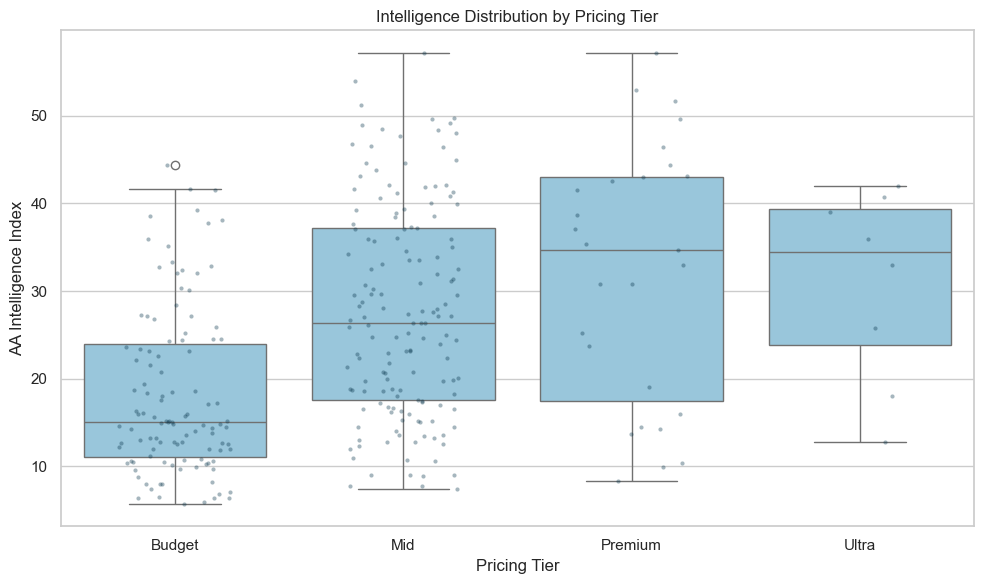

,count,median,mean
pricing_tier,,,
Premium,27,34.7,32.144444
Ultra,8,34.5,30.912500
Mid,151,26.4,27.633775
Budget,111,15.0,18.097297
Free,16,13.1,14.712500
Unknown,133,12.9,14.597744


In [3]:
# Box plot: intelligence distribution by pricing tier
box_df = df_clean[["pricing_tier", "aa_intelligence_index", "model_name"]].dropna(subset=["pricing_tier", "aa_intelligence_index"]).copy()

tier_order = ["Budget", "Mid", "Premium", "Ultra"]
present_tiers = [tier for tier in tier_order if tier in box_df["pricing_tier"].unique()]

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=box_df,
    x="pricing_tier",
    y="aa_intelligence_index",
    order=present_tiers if present_tiers else None,
    color="#8ecae6",
)

sns.stripplot(
    data=box_df,
    x="pricing_tier",
    y="aa_intelligence_index",
    order=present_tiers if present_tiers else None,
    color="#023047",
    alpha=0.35,
    size=3,
    jitter=0.25,
)

ax.set_title("Intelligence Distribution by Pricing Tier")
ax.set_xlabel("Pricing Tier")
ax.set_ylabel("AA Intelligence Index")
plt.tight_layout()
plt.show()

box_df.groupby("pricing_tier")["aa_intelligence_index"].agg(["count", "median", "mean"]).sort_values("median", ascending=False)

## Step 4: Top-5 models per benchmark
For each benchmark (`GPQA Diamond`, `Humanity's Last Exam`, `LiveCodeBench`, `SciCode`, `MATH-500`), extract the top 5 models and visualize the results.

Top-5 models per benchmark


,benchmark,model_name,provider,score
0,GPQA Diamond,Gemini 3.1 Pro Preview,Google,0.941
1,GPQA Diamond,GPT-5.4 (xhigh),OpenAI,0.920
2,GPQA Diamond,GPT-5.3 Codex (xhigh),OpenAI,0.915
3,GPQA Diamond,Gemini 3 Pro Preview (high),Google,0.908
4,GPQA Diamond,GPT-5.2 (xhigh),OpenAI,0.903
5,Humanity's Last Exam,Gemini 3.1 Pro Preview,Google,0.447
6,Humanity's Last Exam,GPT-5.4 (xhigh),OpenAI,0.416
7,Humanity's Last Exam,GPT-5.3 Codex (xhigh),OpenAI,0.399
8,Humanity's Last Exam,Gemini 3 Pro Preview (high),Google,0.372
9,Humanity's Last Exam,"Claude Opus 4.6 (Adaptive Reasoning, Max Effort)",Anthropic,0.367


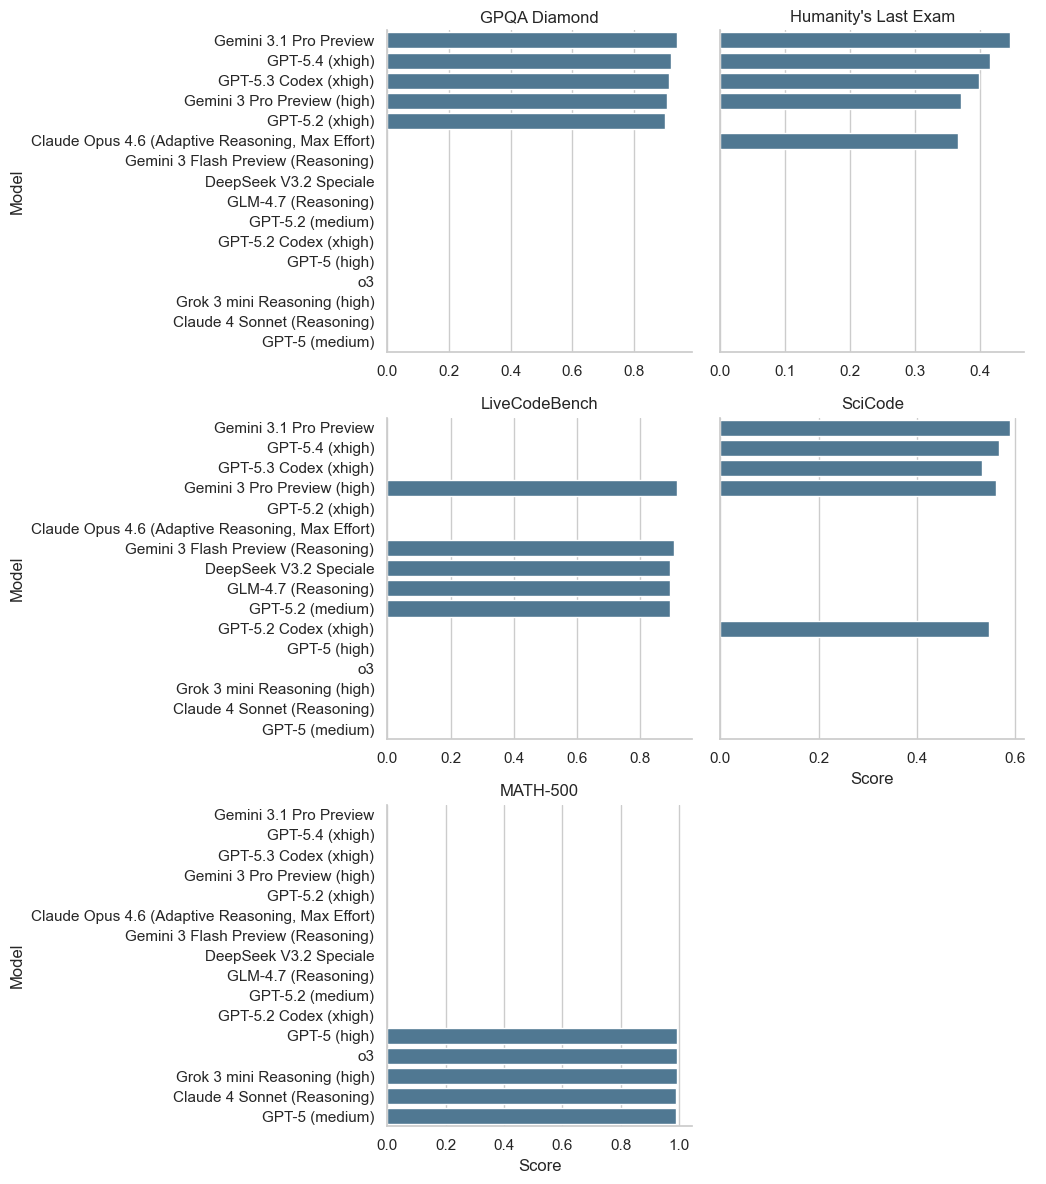

,benchmark,model_name,provider,score
0,GPQA Diamond,Gemini 3.1 Pro Preview,Google,0.941
1,GPQA Diamond,GPT-5.4 (xhigh),OpenAI,0.920
2,GPQA Diamond,GPT-5.3 Codex (xhigh),OpenAI,0.915
3,GPQA Diamond,Gemini 3 Pro Preview (high),Google,0.908
4,GPQA Diamond,GPT-5.2 (xhigh),OpenAI,0.903
5,Humanity's Last Exam,Gemini 3.1 Pro Preview,Google,0.447
6,Humanity's Last Exam,GPT-5.4 (xhigh),OpenAI,0.416
7,Humanity's Last Exam,GPT-5.3 Codex (xhigh),OpenAI,0.399
8,Humanity's Last Exam,Gemini 3 Pro Preview (high),Google,0.372
9,Humanity's Last Exam,"Claude Opus 4.6 (Adaptive Reasoning, Max Effort)",Anthropic,0.367


In [4]:
# Top-5 models on each selected benchmark
benchmark_map = {
    "GPQA Diamond": "gpqa_diamond",
    "Humanity's Last Exam": "humanitys_last_exam",
    "LiveCodeBench": "livecodebench",
    "SciCode": "scicode",
    "MATH-500": "math_500",
}

top5_frames = []

for benchmark_label, col in benchmark_map.items():
    if col not in df_clean.columns:
        continue

    top_n = (
        df_clean[["model_name", "provider", col]]
        .dropna(subset=[col])
        .sort_values(by=col, ascending=False)
        .head(5)
        .rename(columns={col: "score"})
    )
    top_n.insert(0, "benchmark", benchmark_label)
    top5_frames.append(top_n)

if top5_frames:
    top5_benchmarks = pd.concat(top5_frames, ignore_index=True)
else:
    top5_benchmarks = pd.DataFrame(columns=["benchmark", "model_name", "provider", "score"])

# Display as a clean table
print("Top-5 models per benchmark")
display(top5_benchmarks)

# Optional compact visual comparison
if not top5_benchmarks.empty:
    g = sns.catplot(
        data=top5_benchmarks,
        kind="bar",
        x="score",
        y="model_name",
        col="benchmark",
        col_wrap=2,
        sharex=False,
        height=4,
        aspect=1.3,
        color="#457b9d",
    )
    g.set_titles("{col_name}")
    g.set_axis_labels("Score", "Model")
    plt.tight_layout()
    plt.show()

top5_benchmarks